INITIALLY I NEED TO DECLARE n_clusters VALUES  
CENTROIDS => i) RANDOMLY CHOSEN FROM EXISTING DATAPOINTS  
            ii) AVERAGE OF X AND Y AXIS OF EVERY CLUSTER
            iii) REPEAT i AND ii
            iv) tol = 0.001, iter = 300

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [27]:
df = pd.read_csv('../../MACHINE-LEARNING/ML-BASICS/DATASETS/ML_12_KMeans_income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


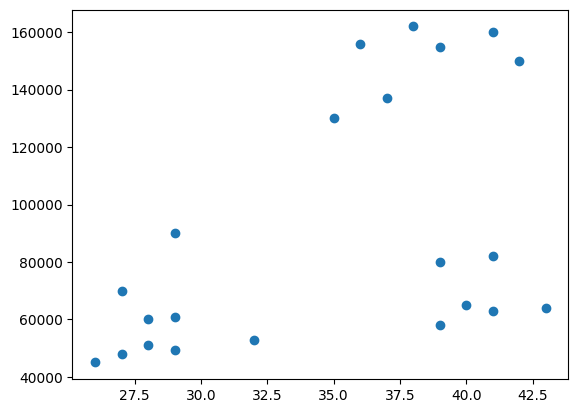

In [28]:
plt.scatter(df['Age'],df['Income($)'])

In [30]:
km = KMeans(n_clusters=3) # 0, 1, 2
y_pred = km.fit_predict(df[['Age','Income($)']])

In [31]:
y_pred

array([0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0])

In [32]:
km.cluster_centers_

array([[3.24166667e+01, 5.72916667e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.63333333e+01, 8.40000000e+04]])

In [33]:
df['cluster'] = y_pred
df

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,1
9,Angelina,35,130000,1


Text(0, 0.5, 'Income')

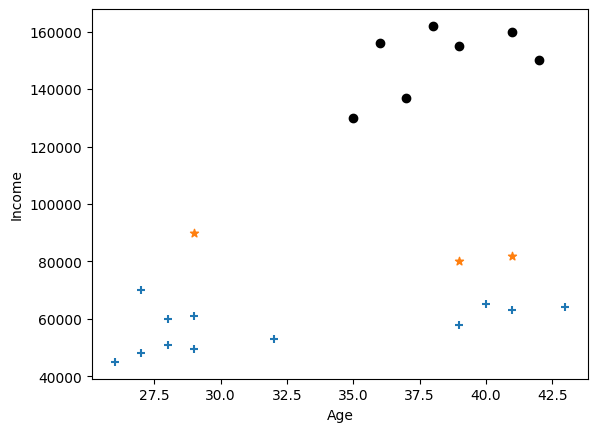

In [34]:
df0 = df[df['cluster']==0]
df1 = df[df['cluster']==1]
df2 = df[df['cluster']==2]

plt.scatter(df0.Age,df0['Income($)'],marker='+')
plt.scatter(df1.Age,df1['Income($)'],color = 'black')
plt.scatter(df2.Age,df2['Income($)'],marker='*')

plt.xlabel('Age')
plt.ylabel('Income')

In [35]:
scaler = MinMaxScaler()
df['Income($)'] = scaler.fit_transform(df[['Income($)']])
df['Age'] = scaler.fit_transform(df[['Age']])
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


In [36]:
km = KMeans(n_clusters=3)
y_pred2 = km.fit_predict(df[['Age','Income($)']])
df['cluster2'] = y_pred2
df

,Name,Age,Income($),cluster,cluster2
0,Rob,0.058824,0.213675,0,1
1,Michael,0.176471,0.384615,2,1
2,Mohan,0.176471,0.136752,0,1
3,Ismail,0.117647,0.128205,0,1
4,Kory,0.941176,0.897436,1,0
5,Gautam,0.764706,0.940171,1,0
6,David,0.882353,0.982906,1,0
7,Andrea,0.705882,1.000000,1,0
8,Brad,0.588235,0.948718,1,0
9,Angelina,0.529412,0.726496,1,0


In [10]:
km.cluster_centers_

array([[0.72268908, 0.8974359 ],
       [0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ]])

Text(0, 0.5, 'Income')

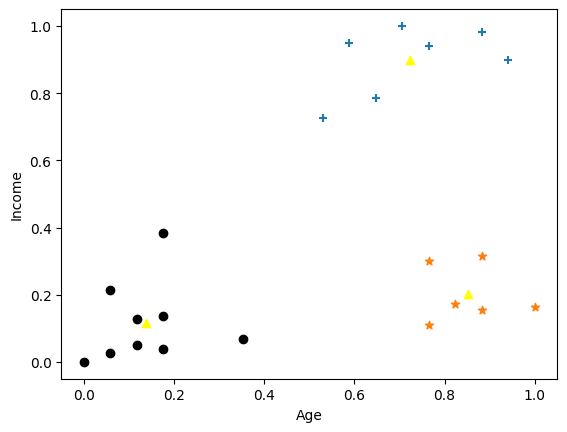

In [37]:
df0 = df[df['cluster2']==0]
df1 = df[df['cluster2']==1]
df2 = df[df['cluster2']==2]

plt.scatter(df0.Age,df0['Income($)'],marker='+')
plt.scatter(df1.Age,df1['Income($)'],color = 'black')
plt.scatter(df2.Age,df2['Income($)'],marker='*')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],marker = '^',color = 'yellow')

plt.xlabel('Age')
plt.ylabel('Income')

In [38]:
sse = []
for k in range(1,10):
    km = KMeans(n_clusters = k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)

In [39]:
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553096,
 0.39237665288019463,
 0.36673634395553495,
 0.23854237996006705,
 0.21446438422046926,
 0.15386320999546685,
 0.1252668649416942]

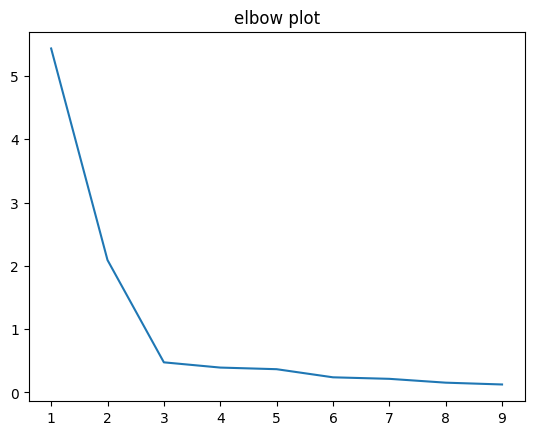

In [40]:
k_rng = range(1,10)
plt.title('elbow plot')
plt.plot(k_rng,sse)

In [15]:
from sklearn.datasets import load_iris
iris = load_iris()

In [16]:
df = pd.DataFrame(iris.data,columns = iris.feature_names)
df['target'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [17]:
df0 = df[df['target']==0]
df1 = df[df['target']==1]
df2 = df[df['target']==2]

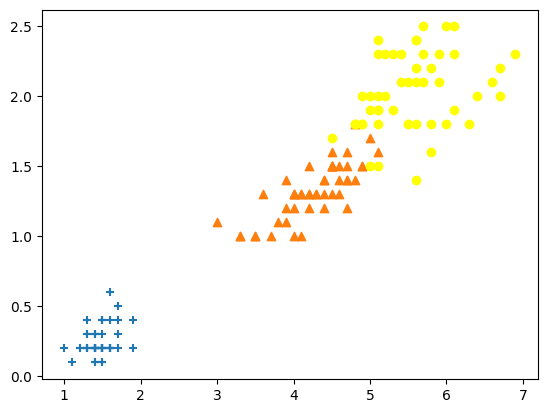

In [18]:
plt.scatter(df0['petal length (cm)'],df0['petal width (cm)'],marker = '+')
plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],marker = '^')
plt.scatter(df2['petal length (cm)'],df2['petal width (cm)'],color = 'yellow')

In [19]:
kme = KMeans(n_clusters = 3)
y_pred = kme.fit_predict(df[['petal length (cm)','petal width (cm)']])
df['cluster'] = y_pred
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,0
146,6.3,2.5,5.0,1.9,2,0
147,6.5,3.0,5.2,2.0,2,0
148,6.2,3.4,5.4,2.3,2,0


In [20]:
df.cluster.value_counts()

cluster
2    54
1    50
0    46
Name: count, dtype: int64

In [21]:
df0 = df[df['cluster']==0]
df1 = df[df['cluster']==1]
df2 = df[df['cluster']==2]

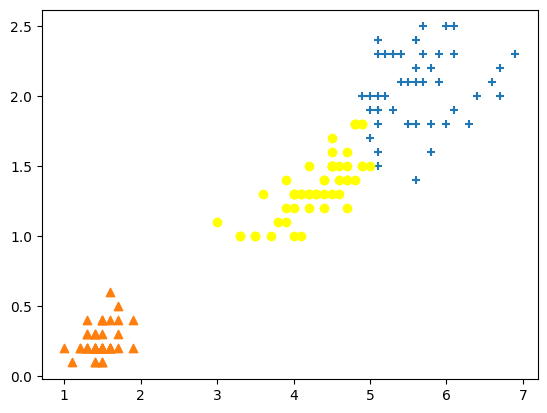

In [22]:
plt.scatter(df0['petal length (cm)'],df0['petal width (cm)'],marker = '+')
plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],marker = '^')
plt.scatter(df2['petal length (cm)'],df2['petal width (cm)'],color = 'yellow')

In [23]:
sse = []
for i in range(1,10):
    kme = KMeans(n_clusters = i)
    kme.fit(df[['petal length (cm)','petal width (cm)']])
    sse.append(kme.inertia_)

In [24]:
sse

[550.8953333333334,
 86.39021984551397,
 31.412885668276978,
 20.2996078034854,
 14.171085855554198,
 11.147086299967425,
 9.321390756302524,
 7.980805438842204,
 6.537997301930808]

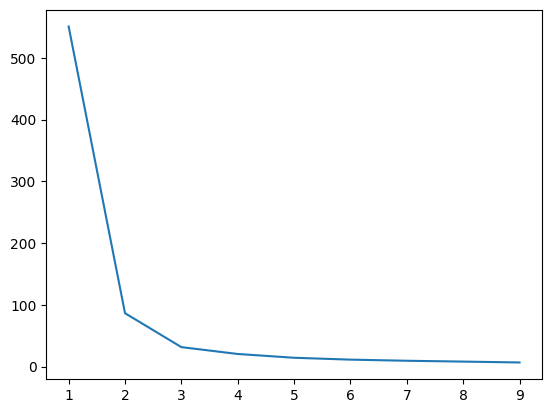

In [25]:
k_rng = range(1,10)
plt.plot(k_rng,sse)